In [1]:
import torch
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F
%matplotlib inline

In [2]:
words = open('names.txt','r').read().splitlines()

In [3]:
charset = sorted(set("".join(words)))

stoi = {s:i+1 for i,s in enumerate(charset)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

vocab_size = len(stoi)

In [4]:
random.shuffle(words)
block_size = 3

In [5]:
def build_dataset(words):
    X = []
    y = []
    for w in words:
        context = [0] * block_size
        for ch in w+'.':
            ix = stoi[ch]
            y.append(ix)
            X.append(context)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    y = torch.tensor(y)
    return X, y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

X_train, y_train = build_dataset(words[:n1])
X_test, y_test = build_dataset(words[n1:n2])
X_val, y_val = build_dataset(words[n2:])

In [20]:
class Linear:
    def __init__(self,fan_in,fan_out,bias=True):
        self.weights = torch.randn((fan_in,fan_out)) / fan_in**0.5
        if bias:
            self.bias = torch.zeros((fan_out)) 
        else:
            self.bias = None

    def __call__(self,x):
        self.out = x @ self.weights
        if self.bias is None:
            return self.out 
        return self.out + self.bias
    
    def parameters(self):
        return [self.weights] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self,dim,eps=1e-5,momentum=0.01):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        #grad variables
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #no-grad variables
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            x_mean = x.mean(0,keepdims=True)
            x_var = x.var(0,keepdims=True,unbiased=True)
        else:
            x_mean = self.running_mean
            x_var = self.running_var
        xhat = (x-x_mean)/torch.sqrt(x_var**2 + self.eps)
        self.out = self.gamma*xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*x_mean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum*x_var
        return self.out

    def parameters(self):
        return [self.gamma,self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

        


In [77]:
n_emb = 10
n_hidden = 100

C = torch.randn((vocab_size,n_emb))
layers = [
  Linear(n_emb * block_size,  n_hidden), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size)
]

with torch.no_grad():
  # layers[-1].weights *= 0.1
  layers[-1].gamma *= 0.1
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weights *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47551


In [78]:
lossi = []

In [79]:
iterations = 10000
batch_size = 256
ud = []

for i in range(iterations):
    ix = torch.randint(0,len(X_train),(batch_size,))
    Xb, yb = X_train[ix], y_train[ix]

    emb = C[Xb]
    x = emb.view(batch_size,-1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x,yb)

    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.01 if i < 5000 else 0.001
    for p in parameters:
        p.data += -lr*p.grad

    if i%1000 == 0:
        print(f'{i:7d}/{iterations:7d}: Loss={loss.item():.4f}')
    lossi.append(loss)
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])
    




      0/  10000: Loss=3.2903
   1000/  10000: Loss=2.9346
   2000/  10000: Loss=2.5903
   3000/  10000: Loss=2.4393
   4000/  10000: Loss=2.3621
   5000/  10000: Loss=2.3518
   6000/  10000: Loss=2.4584
   7000/  10000: Loss=2.2599
   8000/  10000: Loss=2.2097
   9000/  10000: Loss=2.4291


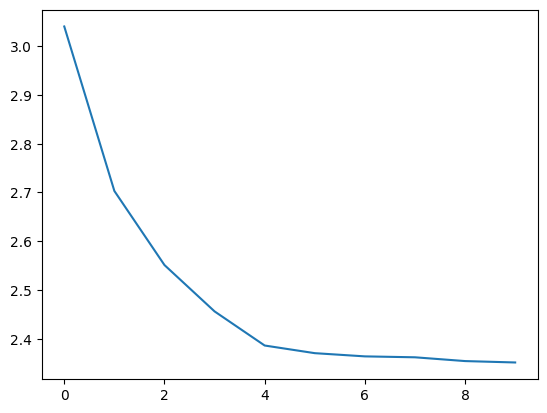

In [80]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [81]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (X_train, y_train),
    'val': (X_val, y_val),
    'test': (X_test, y_test),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.3293845653533936
val 2.3482110500335693


layer 2 (      Tanh): mean -0.00, std 0.51, saturated: 0.50%
layer 5 (      Tanh): mean -0.00, std 0.68, saturated: 7.84%
layer 8 (      Tanh): mean -0.00, std 0.59, saturated: 1.81%
layer 11 (      Tanh): mean +0.00, std 0.64, saturated: 3.77%
layer 14 (      Tanh): mean +0.00, std 0.58, saturated: 1.25%


Text(0.5, 1.0, 'activation distribution')

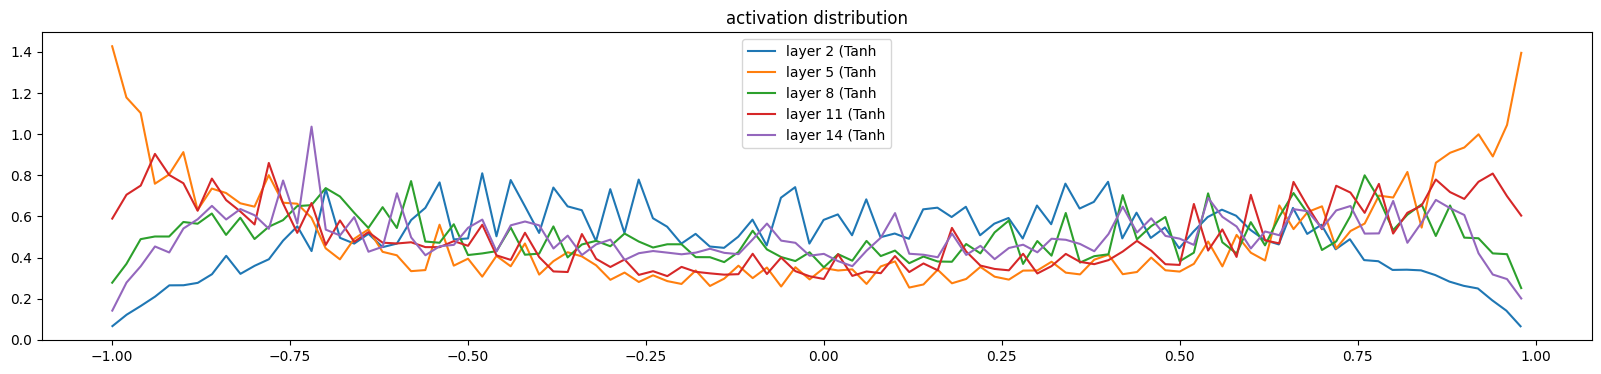

In [82]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

In [66]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

AttributeError: 'NoneType' object has no attribute 'mean'

<Figure size 2000x400 with 0 Axes>

weight   (27, 10) | mean -0.000000 | std 1.194409e-02 | grad:data ratio 1.186464e-02
weight  (30, 100) | mean +0.000072 | std 1.254402e-02 | grad:data ratio 4.149874e-02
weight (100, 100) | mean -0.000071 | std 9.417220e-03 | grad:data ratio 5.636385e-02
weight (100, 100) | mean -0.000047 | std 7.796471e-03 | grad:data ratio 4.746272e-02
weight (100, 100) | mean -0.000064 | std 7.320070e-03 | grad:data ratio 4.426349e-02
weight (100, 100) | mean -0.000011 | std 7.103309e-03 | grad:data ratio 4.254566e-02
weight  (100, 27) | mean -0.000193 | std 1.574714e-02 | grad:data ratio 9.597735e-02


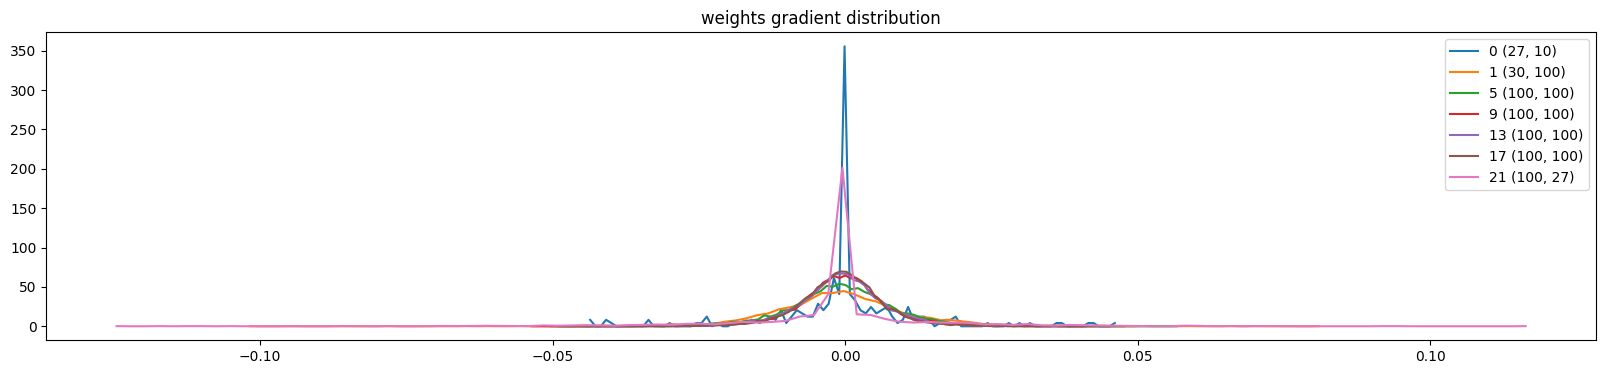

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

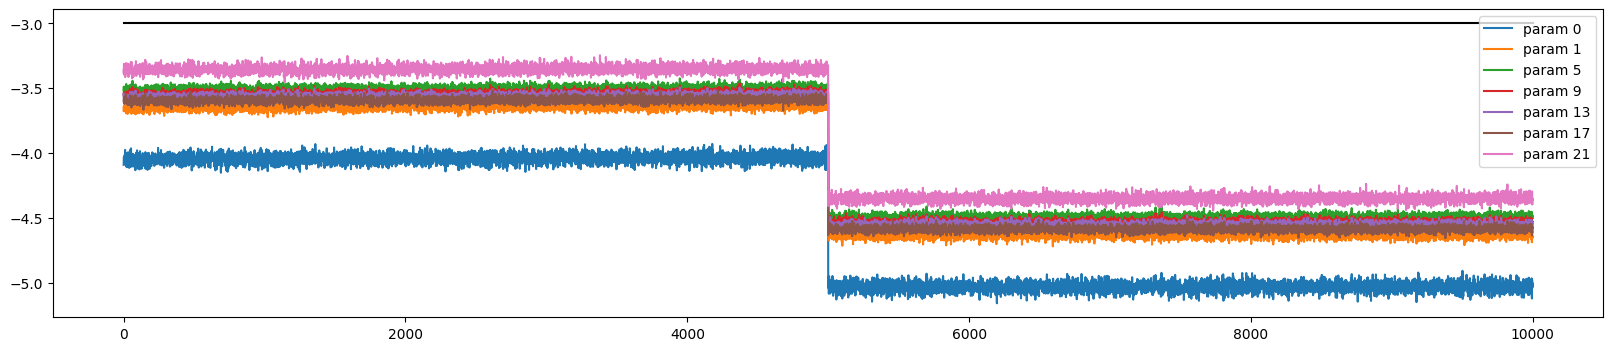

In [67]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [85]:
# sample from the model
# g = torch.Generator().manual_seed(2147483647 + 10)

for layer in layers:
   layer.training = False

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])]
      x = emb.view(emb.shape[0], -1) 
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

kayla.
ziy.
tiva.
dawyandhfire.
bellet.
uel.
ryytechar.
verctanarorien.
lapj.
marls.
der.
tannitanaiana.
mair.
qmen.
wendre.
sair.
adla.
elleyq.
yliannah.
zarrijenia.
